# Small, Local Tests

In [1]:
#Set the main endpoint for dependent code, import the necessary DataFrame (processed in 04-ajl-data_collection.ipynb)
main_endpoint = "LD50"
import pandas as pd
data = pd.read_csv(f"../src/data/{main_endpoint}_pre-grid-search.csv").set_index("Unnamed: 0")
data.head()

,LD50_LM,tp_fp0,tp_fp1,tp_fp2,tp_fp3,tp_fp4,tp_fp5,tp_fp6,tp_fp7,tp_fp8,...,N-CH=N-OH [oxime-type] correction,Ring rx: -OH ortho to -C=N-N-carbon,=C-(C#N)-C#N [dicyano] correction,Aromatic nitrogen-C-C(=S)-N struct corr.,Cyclic ketoxime(>C=N-OH) [1 olefin attach],C=N-O-sulfur(aliphatic) [iminoxy] correc,-S-N(-C(=O)-C)-C(=O)-C struct correction,-Sulfur(+4) charged halide-type,Ring rx: S=P(O)(O)O- / 5-mem (2 nitrogen).1,O=P(-O)(-O)-C-OH correction
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
DTXSID5020281,-0.465339,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID8020961,-0.734786,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID0021834,-0.087091,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID2044347,-1.058925,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DTXSID4025745,-1.022972,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
#Generate parameters for loop in Grid-Search
from numpy import arange
fp_list = ["A", "B", "C", "D", "E"]
increment = 10
weight_list = list(arange(0,100+increment, increment))
params = []
for a in weight_list:
    for b in weight_list:
        if a + b > 100:
            password
        elif a + b == 100:
            params.append([a,b,0,0])
        else:
            for c in weight_list:
                if a+b+c > 100:
                    password
                elif a+b+c == 1000:
                    params.append([a,b,c,0])
                else:
                    for d in weight_list:
                        if a+b+c+d > 100:
                            password
                        elif a+b+c+d == 100:
                            params.append([a,b,c,d])
                        else:
                            password

print(len(params))

286


In [31]:
#Run the grid search
from sklearn.model_selection import GridSearchCV
from genra.rax.skl.hybrid import GenRAPredValueHybrid

#Fingerprint type slices (always true)
slices = [slice(1,730),slice(730,2778), slice(2778,4826), slice(4826, None)]

neighbor_range = range(2,14)
params = {'hybrid_weights': [[0,0,0,1]], 
          'n_neighbors': range(2,14)}

estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices)

Grid3 = GridSearchCV(estimator=estimator, param_grid=params, n_jobs=-1, cv =5, verbose =3, scoring=['r2', 'neg_root_mean_squared_error'], refit = 'neg_root_mean_squared_error')

Best3 = Grid3.fit(data.iloc[:,1:], data.iloc[:,0])
Best3.best_score_, Best3.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


(-0.5736099466527165, {'hybrid_weights': [0, 0, 0, 1], 'n_neighbors': 8})

In [52]:
results = pd.DataFrame(Best3.cv_results_)
results['mean_test_r2'] = sum([results[f'split{i}_test_r2'] for i in range(0,4)])/4
results['mean_test_neg_root_mean_squared_error'] = sum([results[f'split{i}_test_neg_root_mean_squared_error'] for i in range(0,4)])/4
results = results.drop(columns={'mean_fit_time','mean_score_time','std_score_time', 'std_fit_time', 'params', 'split4_test_r2', 'split4_test_neg_root_mean_squared_error'})
results.sort_values("mean_test_neg_root_mean_squared_error", ascending=False)

,param_hybrid_weights,param_n_neighbors,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error
6,"[0, 0, 0, 1]",8,0.291898,0.368160,0.309855,0.281678,0.312898,0.128688,1,-0.673895,-0.686644,-0.784369,-0.723142,-0.717012,0.289358,1
5,"[0, 0, 0, 1]",7,0.288804,0.364387,0.308100,0.278491,0.309946,0.127481,2,-0.675365,-0.688691,-0.785366,-0.724744,-0.718542,0.289931,2
7,"[0, 0, 0, 1]",9,0.277533,0.366402,0.309755,0.282031,0.308930,0.127564,4,-0.680696,-0.687598,-0.784426,-0.722964,-0.718921,0.289906,3
4,"[0, 0, 0, 1]",6,0.288499,0.353757,0.317342,0.276327,0.308981,0.126441,3,-0.675510,-0.694426,-0.780103,-0.725830,-0.718967,0.289761,4
8,"[0, 0, 0, 1]",10,0.264047,0.367310,0.311742,0.284616,0.306929,0.127570,5,-0.687019,-0.687106,-0.783296,-0.721661,-0.719771,0.290046,5
9,"[0, 0, 0, 1]",11,0.254801,0.361913,0.306230,0.295079,0.304506,0.126520,6,-0.691322,-0.690030,-0.786427,-0.716365,-0.721036,0.290536,6
11,"[0, 0, 0, 1]",13,0.252683,0.356570,0.296320,0.294711,0.300071,0.124511,7,-0.692303,-0.692913,-0.792024,-0.716552,-0.723448,0.291669,7
3,"[0, 0, 0, 1]",5,0.277280,0.328188,0.315702,0.275436,0.299151,0.121450,8,-0.680815,-0.708031,-0.781040,-0.726277,-0.724041,0.291468,8
10,"[0, 0, 0, 1]",12,0.247764,0.355193,0.295861,0.294214,0.298258,0.124080,9,-0.694578,-0.693654,-0.792282,-0.716804,-0.724330,0.291967,9
2,"[0, 0, 0, 1]",4,0.251383,0.328900,0.307975,0.241226,0.282371,0.117695,10,-0.692905,-0.707655,-0.785437,-0.743225,-0.732306,0.294659,10


# Imported Data 
(uses above grid search methods on the Virtual Machine for efficiency)

## Preparation and Parameter Selection

In [32]:
#Run this code and paste output into terminal to retrieve results from the VM into the repository
# (current states randomly generated with numpy, list pulled from VM)
for state in [425, 1406, 6888, 5261, 1291, 8492, 7791, 501, 590, 3333]:
    tag = f"percentages{increment}_neighborhood8-8_{state}"
    print(f"scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/{main_endpoint}/big_results_{tag}.csv references/full_print_results/{main_endpoint}")

scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhood8-8_425.csv references/full_print_results/LD50
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhood8-8_1406.csv references/full_print_results/LD50
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhood8-8_6888.csv references/full_print_results/LD50
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhood8-8_5261.csv references/full_print_results/LD50
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhood8-8_1291.csv references/full_print_results/LD50
scp aleary@v2626umcth031.rtord.epa.gov:/home/aleary/Grid-Search_Optimization/outputs/LD50/big_results_percentages5_neighborhoo

In [11]:
#Load the data and remove machine performance and unecessary columns
results_master = []
for state in [425, 1406, 6888, 5261, 1291, 8492, 7791, 501, 590, 3333]:
    results = pd.read_csv(f"../references/full_print_results/LD50/big_results_percentages5_neighborhood8-8_{state}.csv")
    results = results.drop(columns={"Unnamed: 0", "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time", "params"})
    
    #Often, the test [0,0,0,100] will result in null results, so drop that test (causes discussed in OneNote)
    results = results.drop(0)
    results["state"] = [state for _ in range(0,len(results))]
    results_master.append(results)
results= pd.concat(results_master)

In [12]:
#Sort an ensure that indexing is correct for data type adjustments
results = results.sort_values(['state','mean_test_neg_root_mean_squared_error'], ascending=False)
results = results.reset_index()
results = results.drop(columns={"index", "split3_test_r2","split4_test_r2", "split3_test_neg_root_mean_squared_error","split4_test_neg_root_mean_squared_error" })
results.head(10)

,param_hybrid_weights,split0_test_r2,split1_test_r2,split2_test_r2,mean_test_r2,std_test_r2,rank_test_r2,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,state
0,"[15, 65, 15, 5]",0.462430,0.494609,0.436069,0.464369,0.023938,1,-0.628210,-0.641781,-0.638148,-0.636046,0.005736,1,8492
1,"[15, 60, 20, 5]",0.464512,0.491710,0.436873,0.464365,0.022387,2,-0.626993,-0.643619,-0.637693,-0.636101,0.006880,2,8492
2,"[5, 70, 10, 15]",0.461686,0.484846,0.445805,0.464112,0.016030,3,-0.628645,-0.647950,-0.632615,-0.636403,0.008324,3,8492
3,"[15, 75, 5, 5]",0.463395,0.488674,0.439479,0.463849,0.020086,4,-0.627646,-0.645538,-0.636215,-0.636467,0.007307,4,8492
4,"[15, 55, 25, 5]",0.463059,0.488609,0.438921,0.463530,0.020288,6,-0.627843,-0.645579,-0.636532,-0.636651,0.007241,5,8492
5,"[15, 50, 30, 5]",0.465578,0.485235,0.439962,0.463592,0.018536,5,-0.626368,-0.647705,-0.635941,-0.636672,0.008726,6,8492
6,"[15, 70, 10, 5]",0.461004,0.490575,0.438597,0.463392,0.021287,7,-0.629043,-0.644337,-0.636715,-0.636698,0.006244,7,8492
7,"[20, 75, 5, 0]",0.464130,0.488333,0.437408,0.463290,0.020798,8,-0.627216,-0.645753,-0.637389,-0.636786,0.007580,8,8492
8,"[25, 60, 15, 0]",0.464908,0.487099,0.437231,0.463079,0.020400,9,-0.626761,-0.646531,-0.637490,-0.636927,0.008081,9,8492
9,"[20, 55, 20, 5]",0.463161,0.490957,0.434627,0.462915,0.022997,10,-0.627783,-0.644095,-0.638963,-0.636947,0.006810,10,8492


In [13]:
#Process the new DataFrame, reassigning types as needed
new_weights = []
for i in results["param_hybrid_weights"]:
    number_list = i.split(",")
    first = number_list[0][1:]
    last = number_list[-1][:-1]
    new_weights.append([int(first), int(number_list[1]), int(number_list[2]), int(last)])
results["param_hybrid_weights"] = new_weights


#Note that weights imported as a string. This code will amend that for us and replace the string column
#with individual numberical weight columns that can be used in graphing and analysis
morgan_weight = [results["param_hybrid_weights"][i][1] for i in range(0,len(results["param_hybrid_weights"]))]
toxprint_weight = [results["param_hybrid_weights"][i][0] for i in range(0,len(results["param_hybrid_weights"]))]
torsion_weight = [results["param_hybrid_weights"][i][2] for i in range(0,len(results["param_hybrid_weights"]))]
aims_weight = [results["param_hybrid_weights"][i][3] for i in range(0,len(results["param_hybrid_weights"]))]

results["morgan"] = [morgan_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(morgan_weight))]
results["toxprint"] = [toxprint_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(toxprint_weight))]
results["torsion"] = [torsion_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(torsion_weight))]
results["aims"] = [aims_weight[i]/sum(results["param_hybrid_weights"][i]) for i in range(0,len(aims_weight))]


In [14]:
#View optimal results for each state, based on an average of the tests with the top 10 performances as measured
#by rmse
max_results = results.loc[results['rank_test_neg_root_mean_squared_error']<=10]
max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .groupby('state').mean()[['mean_test_r2', 'mean_test_neg_root_mean_squared_error', 'morgan', 'toxprint', 'torsion', 'aims']]

,mean_test_r2,mean_test_neg_root_mean_squared_error,morgan,toxprint,torsion,aims
state,,,,,,
425,0.491514,-0.635204,0.511111,0.250000,0.133333,0.105556
501,0.490151,-0.626798,0.590000,0.225000,0.105000,0.080000
590,0.463352,-0.638555,0.550000,0.265000,0.120000,0.065000
1291,0.472704,-0.644558,0.385000,0.310000,0.230000,0.075000
1406,0.460962,-0.650327,0.695000,0.210000,0.040000,0.055000
3333,0.479198,-0.633410,0.580000,0.260000,0.085000,0.075000
5261,0.494444,-0.629598,0.677778,0.205556,0.094444,0.022222
6888,0.495461,-0.624867,0.677778,0.205556,0.066667,0.050000
7791,0.472136,-0.640034,0.665000,0.165000,0.075000,0.095000


In [15]:
#Remove non-numerical columns, and take a mean of the previous DataFrame to view our prediction for best
#hybrid weight
best_combo = max_results.drop(columns = {'param_hybrid_weights', 'rank_test_r2', 'rank_test_neg_root_mean_squared_error'})\
    .mean()[["morgan", "toxprint", "torsion", "aims", "mean_test_neg_root_mean_squared_error", "mean_test_r2"]]
best_combo_weights = [best_combo['toxprint'], best_combo['morgan'], best_combo['torsion'], best_combo['aims']]
best_combo

morgan                                   0.595876
toxprint                                 0.225773
torsion                                  0.110825
aims                                     0.067526
mean_test_neg_root_mean_squared_error   -0.636181
mean_test_r2                             0.477879
dtype: float64

# Graphs

## Suplot Graph

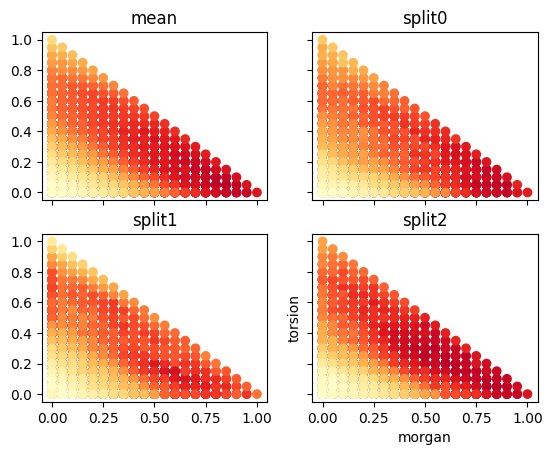

In [63]:
#To test consistency among results.loc[results["state"]==1383], plot one graph type for each split and the mean. 
import matplotlib.pyplot as plt
x = 'morgan'
y = 'torsion'
z = 'neg_root_mean_squared_error'
state = 425
fig, axs = plt.subplots(2,2, sharex=True, sharey=True)
axs[0,0].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'mean_test_{z}'], cmap='YlOrRd')
axs[0,0].set_title('mean')
plt.xlabel(x)
plt.ylabel(y)
axs[0,1].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'split0_test_{z}'], cmap='YlOrRd')
axs[0,1].set_title('split0')
axs[1,0].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'split1_test_{z}'], cmap='YlOrRd')
axs[1,0].set_title('split1')
axs[1,1].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'split2_test_{z}'], cmap='YlOrRd')
axs[1,1].set_title('split2')
# axs[1,2].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'split3_test_{z}'], cmap='YlOrRd')
# axs[1,2].set_title('split3')
# axs[0,2].scatter(results.loc[results["state"]==state][x],results.loc[results["state"]==state][y], c = results.loc[results["state"]==state][f'split4_test_{z}'], cmap='YlOrRd')
# axs[0,2].set_title('split4')

plt.show()

## Individual Graphs Weight1 vs. Weight2

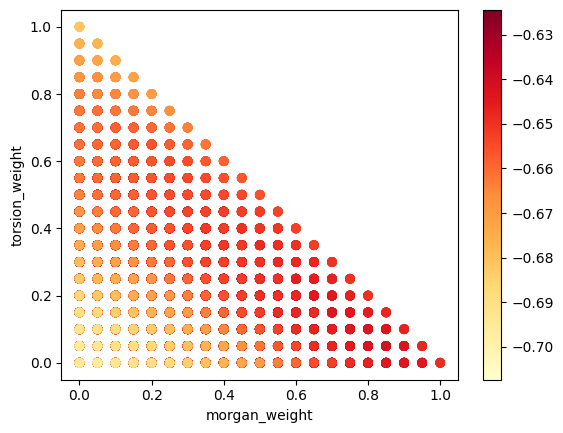

In [64]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['morgan'],results['torsion'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("morgan_weight")
plt.ylabel('torsion_weight')
plt.show()

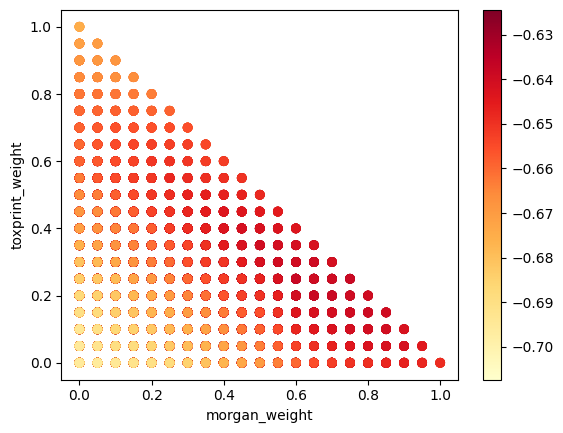

In [65]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['morgan'],results['toxprint'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("morgan_weight")
plt.ylabel('toxprint_weight')
plt.show()

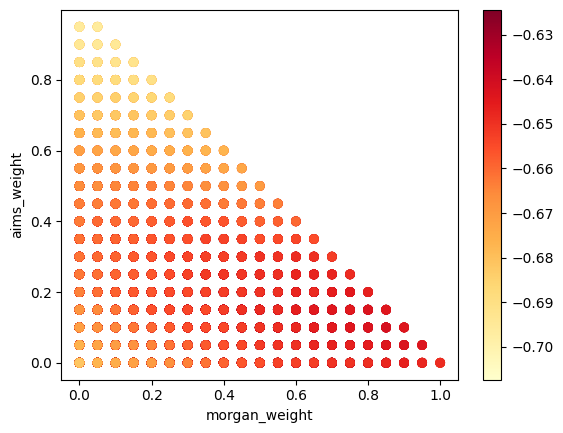

In [66]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['morgan'],results['aims'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("morgan_weight")
plt.ylabel('aims_weight')
plt.show()

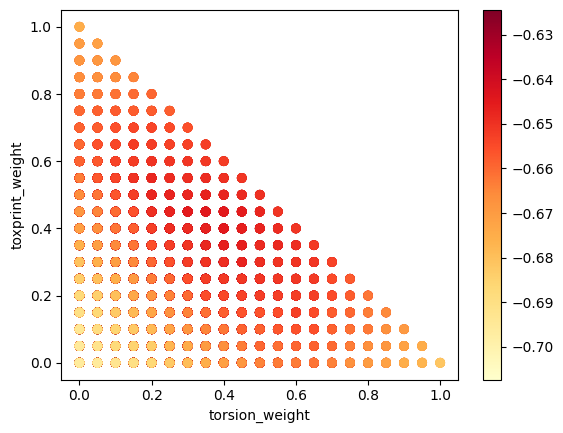

In [67]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['torsion'],results['toxprint'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("torsion_weight")
plt.ylabel('toxprint_weight')
plt.show()

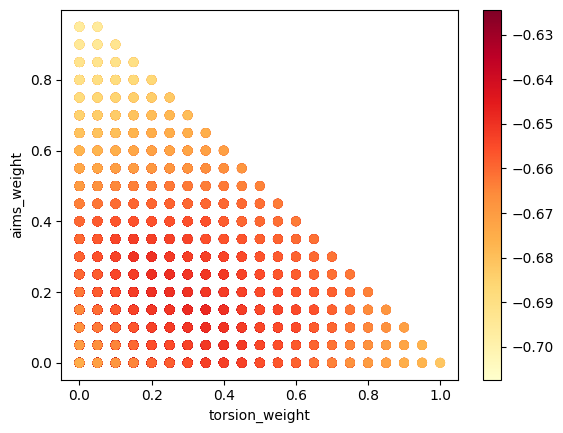

In [68]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['torsion'],results['aims'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("torsion_weight")
plt.ylabel('aims_weight')
plt.show()

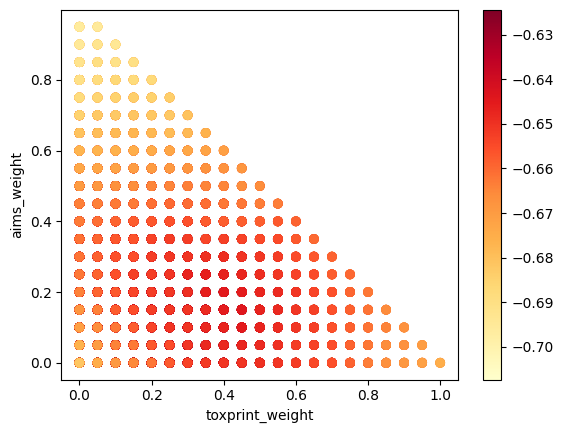

In [69]:
z = results['mean_test_neg_root_mean_squared_error']
plt.scatter(results['toxprint'],results['aims'], c = z, cmap='YlOrRd')
plt.colorbar()
plt.xlabel("toxprint_weight")
plt.ylabel('aims_weight')
plt.show()

## 3-D Graph

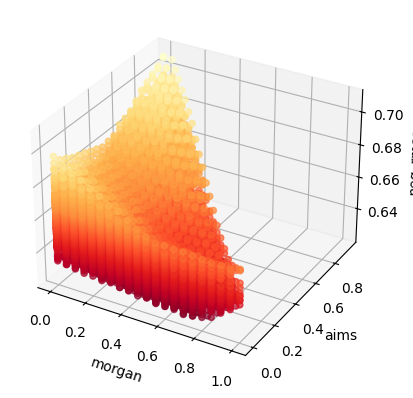

In [70]:
x = results['morgan']
y = results['aims']
z = -results['mean_test_neg_root_mean_squared_error']
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(x,y,z,c=-z,cmap='YlOrRd', alpha=0.7)
ax.set_xlabel('morgan')
ax.set_ylabel('aims')
ax.set_zlabel('neg_rmse')
plt.show()

# Post-Grid-Search Testing

The grid search uses training data to set ideal parameters for the GenRA prediction, but we hold back testing data to verify our results. Now that we have predicted optimal parameters, we can use the below code to test whether those parameters yield the expected results. We also test the performance of full-morgan, full-torsion, and full-toxprint fingerprints as a baseline for comparison. 

Matching the random state of the train_test_split function to that used to generate data ensures that the data is divided up in the same way here as it was during the grid search on the VM. 

In [8]:
#The Jaccard metric as it is currently assigned wants boolean values, so convert the fingerprint columns here
data[data.columns[1:]]=data[data.columns[1:]].astype("bool")

In [16]:
#Test the data including all known data except for the test endpoint
"""This test format, run in the VM, iterates through each state and for each state iterates through the every row 
of test data, fitting GenRA to every other point in the data set and then predicting the y-value for that single
point. These tests are computation-intense since we cannot batch-predict, but give more accurate rmse values (r2 
still based on batch predictions for now)"""
from sklearn.model_selection import train_test_split
from numpy import sqrt
from genra.rax.skl.hybrid import GenRAPredValueHybrid
from sklearn.metrics import r2_score

original_scores = pd.read_csv('ten_test_optimum.csv').drop(columns = {'Unnamed: 0'})
scores = {"state":[], "r2":[], 'rmse':[]}
for state in [7791, 501, 590, 3333]:
    slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, None)]
    x_train, x_test, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=state)
    tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, hybrid_weights=best_combo_weights,metric = 'jaccard')
    y_preds = []

    for x in x_test.iterrows():
        tester.fit(data.loc[data.index != x[0]].iloc[:, 1:], data.loc[data.index != x[0]].iloc[:,0])
        y_preds.append(tester.predict(x[1:]))
    r2 = r2_score(y_test, y_preds)
    rmse = sqrt((sum([(y_preds[i]-y_test.values[i])**2 for i in range(0,len(y_preds))])/len(y_preds)))
    scores['r2'].append(r2)
    scores['rmse'].append(rmse)
    scores['state'].append(state)
    scores_df = pd.DataFrame(scores)
    scores_df = pd.concat([original_scores, scores_df])
    scores_df.to_csv('ten_test_optimum_2.csv')


In [19]:
#A DataFrame storing the results of the above test 
scores_df.reset_index(drop = True)

,state,r2,rmse
0,425,0.526179,[0.5869848]
1,1406,0.559123,[0.57816798]
2,6888,0.496777,[0.63348344]
3,5261,0.531264,[0.60719488]
4,1291,0.514990,[0.60177262]
5,8492,0.526919,[0.63098438]
6,7791,0.510730,[0.6177544789212561]
7,501,0.506215,[0.6291205145770662]
8,590,0.570346,[0.5971945035207993]
9,3333,0.524267,[0.6174795196454724]


In [109]:
#The same test as above, but with pure fingerprints as a control
scores = {"weights":[], "r2":[], 'rmse':[], 'state': []}
for state in [425, 1406, 6888, 5261, 1291, 8492, 7791, 501, 590, 3333]:
    from sklearn.model_selection import train_test_split
    from numpy import sqrt
    weights = [[100,0,0,0], [0,100,0,0], [0,0,100,0]]
    for test in weights:
        slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, None)]
        x_train, x_test, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=state)
        tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, hybrid_weights=test,metric = 'jaccard')
        y_preds = []

        for x in x_test.iterrows():
            tester.fit(data.loc[data.index != x[0]].iloc[:, 1:], data.loc[data.index != x[0]].iloc[:,0])
            y_preds.append(tester.predict(x[1:]))
        r2 = r2_score(y_test, y_preds)
        rmse = sqrt((sum([(y_preds[i]-y_test.values[i])**2 for i in range(0,len(y_preds))])/len(y_preds)))
        scores['r2'].append(r2)
        scores['rmse'].append(rmse)
        scores['state'].append(state)

c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybrid\venv\Lib\site-packages\sklearn\metrics\pairwise.py:2317: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\aleary\OneDrive - Environmental Protection Agency (EPA)\Profile\Documents\Grid Search Optimization\genra-hybr

In [113]:
#The DataFrame for the pure fingerprints
plain_prints_df = pd.DataFrame(scores)
plain_prints_df

,weights,r2,rmse,state
0,"[100, 0, 0, 0]",0.633473,0.516265,425
1,"[0, 100, 0, 0]",0.746831,0.429067,425
2,"[0, 0, 100, 0]",0.707330,0.461327,425
3,"[100, 0, 0, 0]",0.690768,0.484215,1406
4,"[0, 100, 0, 0]",0.770795,0.416877,1406
5,"[0, 0, 100, 0]",0.727076,0.454901,1406
6,"[100, 0, 0, 0]",0.642161,0.534194,6888
7,"[0, 100, 0, 0]",0.742199,0.453416,6888
8,"[0, 0, 100, 0]",0.696266,0.492155,6888
9,"[100, 0, 0, 0]",0.655427,0.520600,5261


## T-test Verification

Unlikely to proceed with this many tests in the future due to extended computation times with increased data size and more specific testing methodology. 

In [ ]:
#Previously used hundred test verification (with weaker rmse values), likely to be deprecated due to 
#increased computation time for newly improved data and rmse values
from sklearn.model_selection import train_test_split
from numpy import sqrt
import random
scores = {"state":[], "r2":[], 'rmse':[]}
hundred_list = [random.randint(0,10000) for _ in range(0,100)]
for state in hundred_list:
    slices = [slice(0,729),slice(729,2777), slice(2777,4825), slice(4825, None)]
    x_train, x_test, y_train, y_test = train_test_split(data.iloc[:,1:], data.iloc[:,0], random_state=state)
    tester = GenRAPredValueHybrid(n_neighbors =8, slices = slices, hybrid_weights=best_combo_weights,metric = 'jaccard')
    
    tester.fit(x_train, y_train)
    y_preds = tester.predict(x_test)
    r2 = tester.score(x_test, y_test)
    rmse = sqrt((sum((y_preds-y_test)**2)/len(y_preds)))
    scores['r2'].append(r2)
    scores['rmse'].append(rmse)
    scores['state'].append(state)

In [349]:
#Hundred test DataFrame
hundred_test_df = pd.DataFrame(scores)
hundred_test_df.head(30)

,state,r2,rmse
0,55,0.385702,0.661294
1,8101,0.427680,0.633858
2,89,0.443439,0.629456
3,1302,0.428617,0.666714
4,4612,0.449707,0.640066
5,9971,0.473935,0.634173
6,7975,0.453033,0.669307
7,7748,0.450756,0.656904
8,9411,0.462021,0.644048
9,5924,0.451270,0.655373


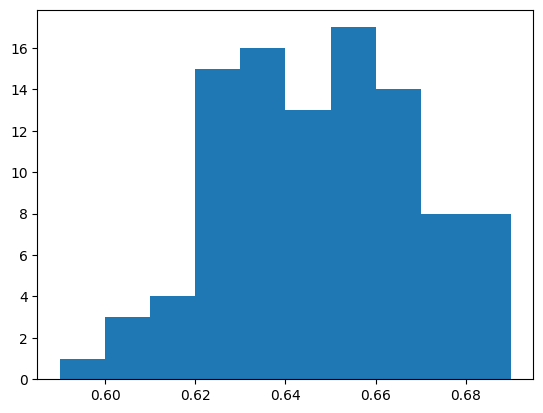

In [362]:
#Verification of shape of hundred test data for t-test
plt.hist(hundred_test_df['rmse'], bins = arange(0.59,0.70, 0.01 ))
plt.show()

In [353]:
hundred_test_df['r2'].mean(),hundred_test_df['r2'].std(), hundred_test_df['rmse'].mean(), hundred_test_df['rmse'].std()

(0.45015821633112035,
 0.030828515122355644,
 0.6484373685416529,
 0.021875429957608095)

In [355]:
#Save the hundred test list for comparison use
hundred_list

[55,
 8101,
 89,
 1302,
 4612,
 9971,
 7975,
 7748,
 9411,
 5924,
 7233,
 9891,
 2009,
 8084,
 4217,
 1814,
 1289,
 4797,
 8456,
 8944,
 5089,
 8871,
 6057,
 2963,
 5631,
 5725,
 5690,
 6166,
 5910,
 4289,
 9488,
 7846,
 9154,
 1746,
 4451,
 3967,
 5102,
 9126,
 459,
 7098,
 1056,
 5280,
 2316,
 8582,
 9856,
 8658,
 7658,
 1367,
 1806,
 9754,
 6659,
 1537,
 6573,
 3755,
 9482,
 9351,
 8562,
 8011,
 5133,
 4833,
 6444,
 9061,
 5248,
 4522,
 6253,
 1324,
 9344,
 6353,
 6899,
 3076,
 8005,
 2777,
 1508,
 3602,
 468,
 5216,
 3046,
 8400,
 9782,
 7663,
 3108,
 6673,
 8975,
 189,
 9415,
 6700,
 6165,
 1778,
 4770,
 465,
 7247,
 9700,
 1143,
 1104,
 9974,
 6638,
 8418,
 3192,
 1775,
 1490]

# ClassyFire Data Incorporation

In [412]:
#Pull data from EPA dev API regarding ClassyFire taxonomy
import requests


class_list = []
superclass_list = []
for chem in data.index:
    url = f"https://hazard-dev.sciencedataexperts.com/api/resolver/classyfire?query={chem}"
    response = requests.get(url)
    response_json = response.json()
    if len(response_json['content'])>0:
        class_list.append(response_json['content'][0]['klass'])
        superclass_list.append(response_json['content'][0]['superklass'])
    else:
        class_list.append('unknown')
        superclass_list.append('unknown')

In [ ]:
#Add superclass and class columns to our data
data['superclass'] = superclass_list
data['class'] = class_list

In [425]:
#Combine related superclasses with few members to create a decently sized superclass
data = data.replace(to_replace = ['Hydrocarbons', "Hydrocarbon derivatives"], value = "Hydrocarbons and derivatives")

In [48]:
#Select only superclasses with more than 100 members for initial testing
superclasses = data.groupby('superclass').count()['LD50_LM'].keys()
testable = []
for name in superclasses:
    if data.groupby('superclass').count()['LD50_LM'].loc[name] > 100:
        testable.append(name)

testable

['Benzenoids',
 'Lipids and lipid-like molecules',
 'Organic acids and derivatives',
 'Organic nitrogen compounds',
 'Organic oxygen compounds',
 'Organohalogen compounds',
 'Organoheterocyclic compounds',
 'Organosulfur compounds',
 'Phenylpropanoids and polyketides',
 'unknown']

In [46]:
#Save our data with ClassyFire information (or pull it back out)
data = pd.read_csv(f"../src/data/{main_endpoint}_pre-grid-search2.csv")

In [49]:
from numpy import sqrt

#Set a temporary class name
class_name = "Benzenoids"

#Create a score function that will measure rmse for only the selected class, allowing us to grid search for 
#performance on predicting those specific chemicals
def rmse_by_class(estimator, X, y, **kwargs):
    y_class = []
    y_pred_class = []
    for value in y.index:
        if data.loc[data.index == value]["superclass"].values[0] == class_name:
            y_class.append(y.loc[y.index == value].values[0])
            
            y_pred_class.append(estimator.predict(X.loc[X.index == value]))

    error = sqrt(sum([((y_class[i]-y_pred_class[i])**2) for i in range(0,len(y_class))])/len(y_class))
    return error[0]



In [ ]:
#Grid search on specific chemical types
from sklearn.metrics import make_scorer
from genra.rax.skl.hybrid import GenRAPredValueHybrid
from sklearn.model_selection import GridSearchCV


#Fingerprint type slices 
slices = [slice(1,730),slice(730,2778), slice(2778,4826), slice(4826, -2)]

neighbor_range = range(8,9)
parameters = {'hybrid_weights': params}

estimator = GenRAPredValueHybrid(metric = 'jaccard', slices = slices, n_neighbors=8)

#Iterate through the testable classes (done in VM, but code saved here)
for class_name in testable:

    Grid3 = GridSearchCV(estimator=estimator, param_grid=parameters, n_jobs=-1, cv =3, verbose =3, scoring=rmse_by_class)

    Best3 = Grid3.fit(data.iloc[:,1:-2], data.iloc[:,0])
    Best3.best_score_, Best3.best_params_

At this point, you will need to pull results back from the VM if running the tests yourself, or alter the code below appropriately. 

In [36]:
#Read in results
ten_morgan = pd.read_csv("../references/full_print_results/LD50/ten_test_optimum_plain.csv").drop(columns = {'Unnamed: 0'})
ten_optimum = pd.read_csv("../references/full_print_results/LD50/ten_test_optimum_2.csv").drop(columns = {'Unnamed: 0'})

#Change the data type of the rmse column
ten_morgan['rmse'] = [float(i[1:-1]) for i in ten_morgan['rmse']]
ten_optimum['rmse'] = [float(i[1:-1]) for i in ten_optimum['rmse']]

#Adjust column names for convenient merging
ten_morgan = ten_morgan.rename(columns = {'r2':'mor_r2', 'rmse':'mor_rmse'})
ten_optimum = ten_optimum.rename(columns = {'r2':'opt_r2', 'rmse':'opt_rmse'})

In [42]:
#Combine results into one Data Frame and view
state_results = pd.merge(ten_optimum, ten_morgan, on = 'state')
state_results['r2_change'] = state_results['opt_r2']-state_results['mor_r2']
state_results['rmse_change'] = state_results['opt_rmse'] - state_results['mor_rmse']
state_results

,state,opt_r2,opt_rmse,mor_r2,mor_rmse,r2_change,rmse_change
0,425,0.526179,0.586985,0.505959,0.599379,0.020220,-0.012394
1,1406,0.559123,0.578168,0.538701,0.591407,0.020422,-0.013239
2,6888,0.496777,0.633483,0.470577,0.649765,0.026200,-0.016281
3,5261,0.531264,0.607195,0.503148,0.625140,0.028115,-0.017945
4,1291,0.514990,0.601773,0.496886,0.612901,0.018104,-0.011129
5,8492,0.526919,0.630984,0.496083,0.651224,0.030836,-0.020240
6,7791,0.510730,0.617754,0.485606,0.633417,0.025124,-0.015662
7,501,0.506215,0.629121,0.483008,0.643735,0.023208,-0.014614
8,590,0.570346,0.597194,0.534582,0.621553,0.035765,-0.024359
9,3333,0.524267,0.617480,0.501251,0.632240,0.023016,-0.014760


In [43]:
#View average changes in r2 and rmse
state_results.mean()[['r2_change', 'rmse_change']]

r2_change      0.025101
rmse_change   -0.016062
dtype: float64